# Phase 12: Target Distribution EDA
Analyzing the massive right-skew of mega-disaster outliers and applying `log1p` normalization for the XGBoost engine.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")


In [2]:
# Load the Atmospheric Impact Matrix
df = pd.read_csv('../data/processed/atmospheric_impact_matrix.csv')

# Dynamic resolution of target columns (depending on exact EM-DAT formatting)
target_affected = 'Total Affected' if 'Total Affected' in df.columns else df.columns[df.columns.str.contains('Affected')][0]
target_damage = "Total Damage ('000 US$)" if "Total Damage ('000 US$)" in df.columns else df.columns[df.columns.str.contains('Damage')][0]

df[target_affected] = df[target_affected].fillna(0)
df[target_damage] = df[target_damage].fillna(0)

print(f"Dataset shape: {df.shape}")


Dataset shape: (10027, 28)


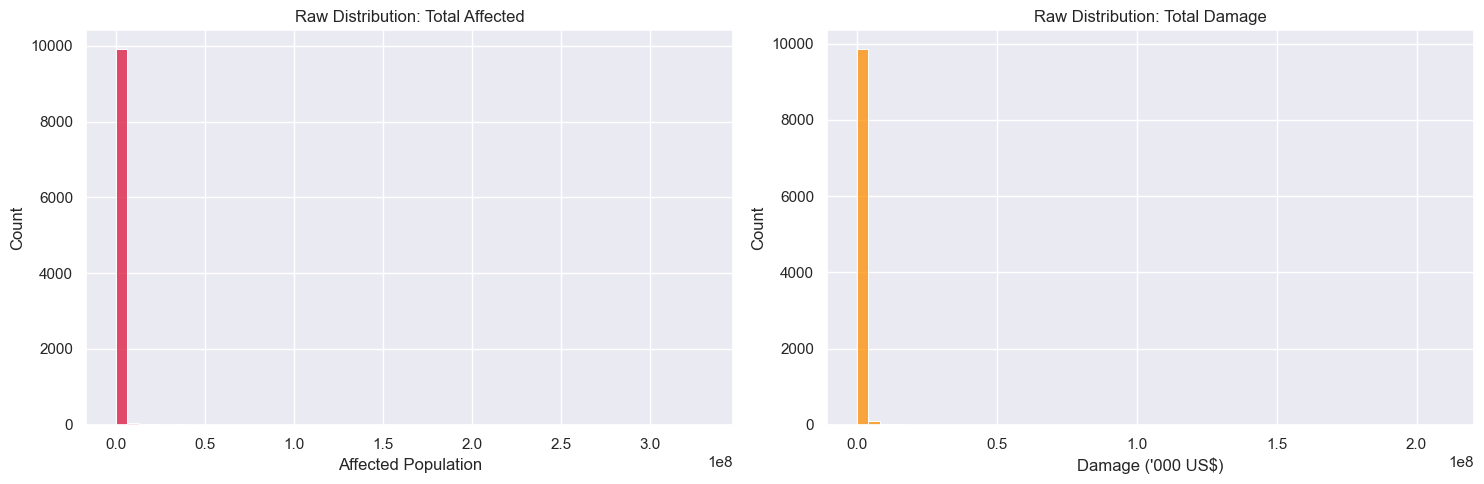

In [3]:
# 1. Raw Distributions (The Mega-Disaster Skew)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df[target_affected], bins=50, ax=axes[0], color='crimson')
axes[0].set_title('Raw Distribution: Total Affected')
axes[0].set_xlabel('Affected Population')

sns.histplot(df[target_damage], bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('Raw Distribution: Total Damage')
axes[1].set_xlabel("Damage ('000 US$)")

plt.tight_layout()
plt.show()


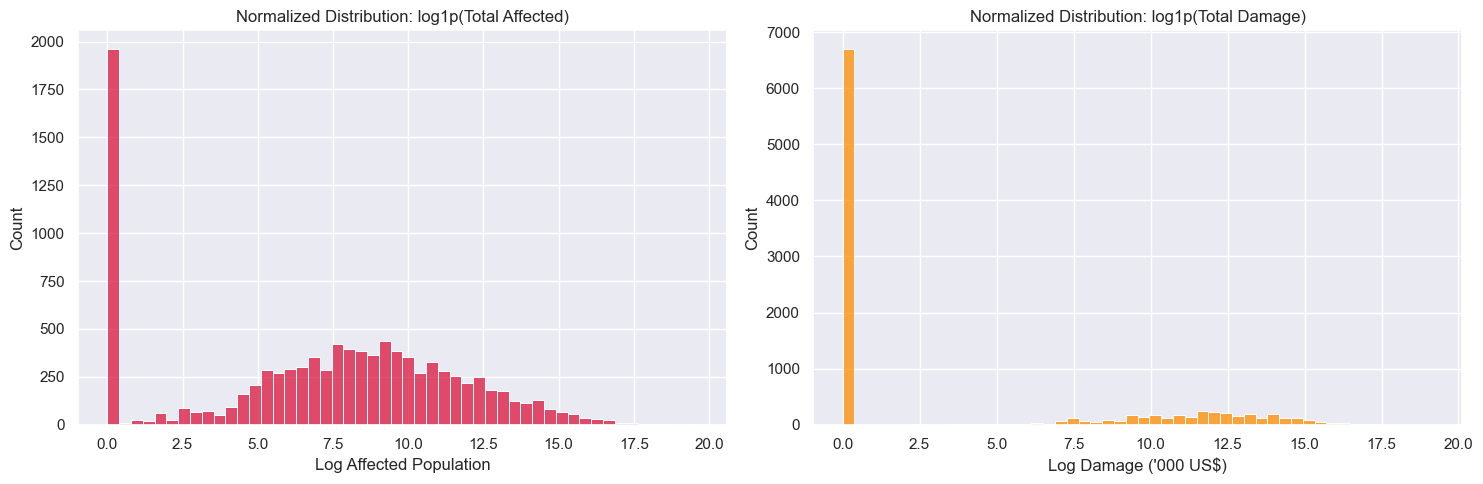

In [4]:
# 2. Log1p Transformation (Normalization for XGBoost)
df['log_total_affected'] = np.log1p(df[target_affected])
df['log_total_damage'] = np.log1p(df[target_damage])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['log_total_affected'], bins=50, ax=axes[0], color='crimson')
axes[0].set_title('Normalized Distribution: log1p(Total Affected)')
axes[0].set_xlabel('Log Affected Population')

sns.histplot(df['log_total_damage'], bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('Normalized Distribution: log1p(Total Damage)')
axes[1].set_xlabel("Log Damage ('000 US$)")

plt.tight_layout()
plt.show()
